In [1]:
import pandas as pd      # 表格数据处理
import numpy as np       # 数值计算
import matplotlib.pyplot as plt  # 绘图

from jqdata import *

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

analysis_date = pd.to_datetime('2025-01-22')
analysis_date = pd.to_datetime(get_trade_days(end_date=analysis_date, count=1)[0])

print(f"✅ 环境准备完成！分析日期: {analysis_date.date()}")

✅ 环境准备完成！分析日期: 2025-01-22


In [2]:
## 获取股票池
stocks_300 = get_index_stocks('000300.XSHG', date=analysis_date)

print(f"✅ 沪深300成分股数量: {len(stocks_300)}")
print(f"📋 前5只股票代码: {stocks_300[:5]}")

## 常用
## 000300.XSHG 沪深300
## 000905.XSHG 中证500
## 000852.XSHG 中证1000
## 399006.XSHE 创业板指

✅ 沪深300成分股数量: 300
📋 前5只股票代码: ['000001.XSHE', '000002.XSHE', '000063.XSHE', '000100.XSHE', '000157.XSHE']


In [3]:
## 获取历史行情数据
hist_days = get_trade_days(end_date=analysis_date, count=180)
future_days = get_trade_days(start_date=analysis_date, count=6)  # 含当日+未来5日
start_date = hist_days[0]
end_date = future_days[-1]

In [4]:
print(hist_days)
print(future_days)

[2024-04-30 2024-05-06 2024-05-07 2024-05-08 2024-05-09 2024-05-10
 2024-05-13 2024-05-14 2024-05-15 2024-05-16 2024-05-17 2024-05-20
 2024-05-21 2024-05-22 2024-05-23 2024-05-24 2024-05-27 2024-05-28
 2024-05-29 2024-05-30 2024-05-31 2024-06-03 2024-06-04 2024-06-05
 2024-06-06 2024-06-07 2024-06-11 2024-06-12 2024-06-13 2024-06-14
 2024-06-17 2024-06-18 2024-06-19 2024-06-20 2024-06-21 2024-06-24
 2024-06-25 2024-06-26 2024-06-27 2024-06-28 2024-07-01 2024-07-02
 2024-07-03 2024-07-04 2024-07-05 2024-07-08 2024-07-09 2024-07-10
 2024-07-11 2024-07-12 2024-07-15 2024-07-16 2024-07-17 2024-07-18
 2024-07-19 2024-07-22 2024-07-23 2024-07-24 2024-07-25 2024-07-26
 2024-07-29 2024-07-30 2024-07-31 2024-08-01 2024-08-02 2024-08-05
 2024-08-06 2024-08-07 2024-08-08 2024-08-09 2024-08-12 2024-08-13
 2024-08-14 2024-08-15 2024-08-16 2024-08-19 2024-08-20 2024-08-21
 2024-08-22 2024-08-23 2024-08-26 2024-08-27 2024-08-28 2024-08-29
 2024-08-30 2024-09-02 2024-09-03 2024-09-04 2024-09-05 2024-0

In [5]:
start_date

datetime.date(2024, 4, 30)

In [6]:
end_date

datetime.date(2025, 2, 6)

In [7]:
prices = get_price(
    stocks_300,
    start_date=start_date,
    end_date=end_date,
    frequency='daily',         # 日线数据
    fields=['close', 'volume', 'money'],  # 收盘价、成交量、成交额
    fq='pre',                  # 前复权（重要！）
    panel=False                # 返回长格式DataFrame
)
print(prices.shape)
print(prices.head())

(55500, 5)
        time         code  close       volume         money
0 2024-04-30  000001.XSHE   9.36  152732726.0  1.431408e+09
1 2024-05-06  000001.XSHE   9.44  205722094.0  1.953817e+09
2 2024-05-07  000001.XSHE   9.44  125346953.0  1.176786e+09
3 2024-05-08  000001.XSHE   9.31  140883010.0  1.318612e+09
4 2024-05-09  000001.XSHE   9.33  123317981.0  1.150727e+09


In [8]:
## 计算流动性指标
## 100w
## Stock A: 10Y
## STock B: 100w

In [9]:
#    time        code         close
# 0  2023-11-01  000001.XSHE  10.5
# 1  2023-11-01  000002.XSHE  15.2
# 2  2023-11-02  000001.XSHE  10.6
# ...
# （每行是一个 时间×股票 的组合）

In [10]:
"""
time        000001.XSHE  000002.XSHE  ...
2023-11-01  10.5         15.2         ...
2023-11-02  10.6         15.5         ...
...
（行=时间，列=股票代码）
"""

'\ntime        000001.XSHE  000002.XSHE  ...\n2023-11-01  10.5         15.2         ...\n2023-11-02  10.6         15.5         ...\n...\n（行=时间，列=股票代码）\n'

In [11]:
## pivot

close_df = prices.pivot(index='time', columns='code', values='close').sort_index()
print(close_df.head())

code        000001.XSHE  000002.XSHE     ...       688599.XSHG  688981.XSHG
time                                     ...                               
2024-04-30         9.36         7.41     ...             20.59        41.91
2024-05-06         9.44         7.46     ...             20.71        42.56
2024-05-07         9.44         7.52     ...             20.75        42.71
2024-05-08         9.31         7.20     ...             20.26        42.16
2024-05-09         9.33         7.30     ...             21.08        43.72

[5 rows x 300 columns]


In [12]:
money_df = prices.pivot(index='time', columns='code', values='money').sort_index()
print(money_df.head())

code         000001.XSHE   000002.XSHE      ...        688599.XSHG   688981.XSHG
time                                        ...                                 
2024-04-30  1.431408e+09  4.741698e+09      ...       4.615943e+08  9.880253e+08
2024-05-06  1.953817e+09  3.996922e+09      ...       3.377182e+08  9.412835e+08
2024-05-07  1.176786e+09  3.134400e+09      ...       2.684206e+08  5.505738e+08
2024-05-08  1.318612e+09  2.011058e+09      ...       2.341160e+08  4.726734e+08
2024-05-09  1.150727e+09  2.387599e+09      ...       4.909437e+08  1.351312e+09

[5 rows x 300 columns]


In [13]:
## 计算最近20日的平均成交额
avg_money_20d = money_df.loc[:analysis_date].tail(20).mean()  # mean()默认对每列求平均
print(avg_money_20d)

code
000001.XSHE    1.238461e+09
000002.XSHE    1.140553e+09
000063.XSHE    1.145156e+10
000100.XSHE    2.096567e+09
000157.XSHE    4.164559e+08
000166.XSHE    4.367572e+08
000301.XSHE    1.132159e+08
000333.XSHE    2.074811e+09
000338.XSHE    1.565319e+09
000408.XSHE    3.123393e+08
000425.XSHE    4.955609e+08
000538.XSHE    3.892269e+08
000568.XSHE    1.232002e+09
000596.XSHE    4.571660e+08
000617.XSHE    4.335773e+08
000625.XSHE    1.094504e+09
000630.XSHE    4.593307e+08
000651.XSHE    2.045677e+09
000661.XSHE    2.998692e+08
000708.XSHE    1.494287e+08
000725.XSHE    2.214559e+09
000768.XSHE    6.098726e+08
000776.XSHE    5.164307e+08
000786.XSHE    5.667362e+08
000792.XSHE    5.995923e+08
000800.XSHE    6.981086e+07
000807.XSHE    8.059687e+08
000858.XSHE    2.300491e+09
000876.XSHE    1.600886e+08
000895.XSHE    2.933111e+08
                   ...     
603369.XSHG    2.936649e+08
603392.XSHG    1.934203e+08
603501.XSHG    2.022902e+09
603659.XSHG    3.079495e+08
603799.XSHG    

In [14]:
top_10_liquid = avg_money_20d.nlargest(10)
print("📊 流动性Top 10（日均成交额）:")
for stock_code, money in top_10_liquid.items():
    print(f"  {stock_code}: {money/1e8:.2f}亿元")

📊 流动性Top 10（日均成交额）:
  300059.XSHE: 118.25亿元
  000063.XSHE: 114.52亿元
  688981.XSHG: 77.04亿元
  688256.XSHG: 57.56亿元
  300750.XSHE: 53.58亿元
  603986.XSHG: 49.17亿元
  300308.XSHE: 48.66亿元
  000977.XSHE: 48.49亿元
  603019.XSHG: 44.47亿元
  688041.XSHG: 43.65亿元


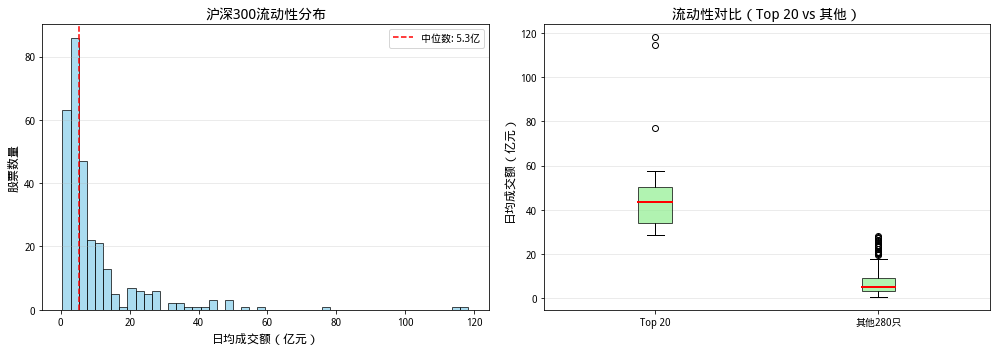

💡 洞察：大部分股票集中在低流动性区间，流动性呈现长尾分布


In [15]:
# 绘制流动性分布图
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：流动性直方图
ax1.hist(avg_money_20d / 1e8, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('日均成交额（亿元）', fontsize=12)
ax1.set_ylabel('股票数量', fontsize=12)
ax1.set_title('沪深300流动性分布', fontsize=14, fontweight='bold')
ax1.axvline(avg_money_20d.median() / 1e8, color='red', linestyle='--',
            label=f'中位数: {avg_money_20d.median()/1e8:.1f}亿')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 右图：Top 20 vs 其他的箱线图对比
top_20_money = avg_money_20d.nlargest(20)
others_money = avg_money_20d[~avg_money_20d.index.isin(top_20_money.index)]

ax2.boxplot([top_20_money / 1e8, others_money / 1e8],
            labels=['Top 20', '其他280只'],
            patch_artist=True,
            boxprops=dict(facecolor='lightgreen', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('日均成交额（亿元）', fontsize=12)
ax2.set_title('流动性对比（Top 20 vs 其他）', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 洞察：大部分股票集中在低流动性区间，流动性呈现长尾分布")

In [16]:
## 聚宽财务表
'''
tables = {
    'valuation': '估值数据（PE、PB、市值）',
    'indicator': '财务指标（ROE、增长率、利润率）',
    'income': '利润表（营收、净利润）',
    'balance': '资产负债表（资产、负债）',
}
'''

"\ntables = {\n    'valuation': '估值数据（PE、PB、市值）',\n    'indicator': '财务指标（ROE、增长率、利润率）',\n    'income': '利润表（营收、净利润）',\n    'balance': '资产负债表（资产、负债）',\n}\n"

In [17]:
## query()

## 1. 构建查询
## 2. 添加筛选
## 3. 执行查询

In [18]:
## 1. 构建查询
q = query(
    valuation.code,
    valuation.pe_ratio,
    valuation.pb_ratio,
)

In [19]:
## 2. 添加筛选

q = q.filter(
    valuation.code.in_(stocks_300)  # 只要沪深300
)

In [20]:
## 3. 执行查询

df_valuation = get_fundamentals(q, date=analysis_date)


In [21]:
print(len(df_valuation))

300


In [22]:
print(df_valuation.head())

          code  pe_ratio  pb_ratio
0  000001.XSHE    4.6233    0.5118
1  000002.XSHE   -4.3167    0.3577
2  000063.XSHE   21.9286    2.8477
3  000100.XSHE   45.2531    1.8172
4  000157.XSHE   16.3257    1.0834


In [23]:
q = query(
    # ========== valuation 表 ==========
    valuation.code,
    valuation.pe_ratio,          # 市盈率
    valuation.pb_ratio,          # 市净率
    valuation.market_cap,        # 总市值（亿元）

    # ========== indicator 表 ==========
    indicator.roe,               # ROE（净资产收益率）
    indicator.inc_revenue_year_on_year,  # 营收同比增长率(%)
).filter(
    valuation.code.in_(stocks_300)
)
df_data = get_fundamentals(q, date=analysis_date)


In [24]:
df_data.head()

,code,pe_ratio,pb_ratio,market_cap,roe,inc_revenue_year_on_year
0,000001.XSHE,4.6233,0.5118,2152.1163,2.85,-11.72
1,000002.XSHE,-4.3167,0.3577,837.5358,-3.40,-13.76
2,000063.XSHE,21.9286,2.8477,2059.3118,3.05,-3.94
3,000100.XSHE,45.2531,1.8172,963.3668,1.01,-10.75
4,000157.XSHE,16.3257,1.0834,618.7408,1.51,-13.89


In [25]:
df_data.isnull().sum()

code                        0
pe_ratio                    0
pb_ratio                    0
market_cap                  0
roe                         0
inc_revenue_year_on_year    0
dtype: int64

In [26]:
"""
聚宽会自动按股票代码（code）关联表：

valuation表           indicator表
┌──────────────┐      ┌──────────────┐
│ code   PE    │      │ code   ROE   │
│ 000001 10.5  │ ┐    │ 000001 15.2  │
│ 000002 12.3  │ ├─→  │ 000002 18.5  │
└──────────────┘ ┘    └──────────────┘
        ↓
  自动JOIN成一张表
┌─────────────────────┐
│ code   PE    ROE    │
│ 000001 10.5  15.2   │
│ 000002 12.3  18.5   │
└─────────────────────┘
"""

'\n聚宽会自动按股票代码（code）关联表：\n\nvaluation表           indicator表\n┌──────────────┐      ┌──────────────┐\n│ code   PE    │      │ code   ROE   │\n│ 000001 10.5  │ ┐    │ 000001 15.2  │\n│ 000002 12.3  │ ├─→  │ 000002 18.5  │\n└──────────────┘ ┘    └──────────────┘\n        ↓\n  自动JOIN成一张表\n┌─────────────────────┐\n│ code   PE    ROE    │\n│ 000001 10.5  15.2   │\n│ 000002 12.3  18.5   │\n└─────────────────────┘\n'

In [30]:
## 数据清洗
print("⚠️ 数据异常情况分析:")
print(f"PE为负的股票: {(df_data['pe_ratio'] < 0).sum()}只")
print(f"PB为负的股票: {(df_data['pb_ratio'] < 0).sum()}只")
print(f"ROE缺失的股票: {df_data['roe'].isnull().sum()}只")



⚠️ 数据异常情况分析:
PE为负的股票: 22只
PB为负的股票: 0只
ROE缺失的股票: 0只


In [31]:
df_clean = df_data.copy()
print(f"清洗前: {len(df_clean)}只股票")

清洗前: 300只股票


In [32]:
## step1 删除核心指标缺失的股票
df_clean = df_clean.dropna(subset=['pe_ratio', 'pb_ratio', 'roe'])
print(f"删除缺失值后: {len(df_clean)}只")


删除缺失值后: 300只


In [33]:
## step2: 过滤ST和新上市的股票
## get_extras

In [34]:
is_st = get_extras(
    'is_st',
    df_clean['code'].tolist(), # 只查当前剩余的股票
    start_date=analysis_date,
    end_date=analysis_date,
    df=True
).iloc[0] # 取第一行（因为只查了一天）

In [35]:
is_st

000001.XSHE    False
000002.XSHE    False
000063.XSHE    False
000100.XSHE    False
000157.XSHE    False
000166.XSHE    False
000301.XSHE    False
000333.XSHE    False
000338.XSHE    False
000408.XSHE    False
000425.XSHE    False
000538.XSHE    False
000568.XSHE    False
000596.XSHE    False
000617.XSHE    False
000625.XSHE    False
000630.XSHE    False
000651.XSHE    False
000661.XSHE    False
000708.XSHE    False
000725.XSHE    False
000768.XSHE    False
000776.XSHE    False
000786.XSHE    False
000792.XSHE    False
000800.XSHE    False
000807.XSHE    False
000858.XSHE    False
000876.XSHE    False
000895.XSHE    False
               ...  
603369.XSHG    False
603392.XSHG    False
603501.XSHG    False
603659.XSHG    False
603799.XSHG    False
603806.XSHG    False
603833.XSHG    False
603986.XSHG    False
603993.XSHG    False
605117.XSHG    False
605499.XSHG    False
688008.XSHG    False
688009.XSHG    False
688012.XSHG    False
688036.XSHG    False
688041.XSHG    False
688082.XSHG  

In [36]:
## 找出所有st的股票代码
st_list = is_st[is_st].index.tolist()
print(st_list)

[]


In [37]:
# 过滤操作
df_clean = df_clean[~df_clean['code'].isin(st_list)]

In [38]:
## 过滤 新上市股票 
listed_cutoff = get_trade_days(end_date=analysis_date, count=60)[0]
print(listed_cutoff)

2024-10-30


In [39]:
all_securities = get_all_securities(types=['stock'], date=analysis_date)

In [40]:
all_securities

,display_name,name,start_date,end_date,type
000001.XSHE,平安银行,PAYH,1991-04-03,2200-01-01,stock
000002.XSHE,万科A,WKA,1991-01-29,2200-01-01,stock
000004.XSHE,*ST国华,*STGH,1990-12-01,2200-01-01,stock
000006.XSHE,深振业A,SZYA,1992-04-27,2200-01-01,stock
000007.XSHE,全新好,QXH,1992-04-13,2200-01-01,stock
000008.XSHE,神州高铁,SZGT,1992-05-07,2200-01-01,stock
000009.XSHE,中国宝安,ZGBA,1991-06-25,2200-01-01,stock
000010.XSHE,美丽生态,MLST,1995-10-27,2200-01-01,stock
000011.XSHE,深物业A,SWYA,1992-03-30,2200-01-01,stock
000012.XSHE,南玻A,NBA,1992-02-28,2200-01-01,stock


In [41]:
eligible_listed = all_securities[all_securities['start_date'] <= listed_cutoff].index
print(eligible_listed)

Index(['000001.XSHE', '000002.XSHE', '000004.XSHE', '000006.XSHE',
       '000007.XSHE', '000008.XSHE', '000009.XSHE', '000010.XSHE',
       '000011.XSHE', '000012.XSHE',
       ...
       '688787.XSHG', '688788.XSHG', '688789.XSHG', '688793.XSHG',
       '688798.XSHG', '688799.XSHG', '688800.XSHG', '688819.XSHG',
       '688981.XSHG', '689009.XSHG'],
      dtype='object', length=5106)


In [43]:
# 只保留上市日期超过60天
df_clean = df_clean[df_clean['code'].isin(eligible_listed)]
print(df_clean)

            code            ...             inc_revenue_year_on_year
0    000001.XSHE            ...                               -11.72
1    000002.XSHE            ...                               -13.76
2    000063.XSHE            ...                                -3.94
3    000100.XSHE            ...                               -10.75
4    000157.XSHE            ...                               -13.89
5    000166.XSHE            ...                                62.74
6    000301.XSHE            ...                                -6.03
7    000333.XSHE            ...                                 8.05
8    000338.XSHE            ...                                -8.82
9    000408.XSHE            ...                               -59.65
10   000425.XSHE            ...                                -6.37
11   000538.XSHE            ...                                 0.86
12   000568.XSHE            ...                                 0.67
13   000596.XSHE            ...   

In [44]:
len(df_clean)

300

In [45]:
## step3: 过滤不可用倒数的指标
df_clean = df_clean[
    (df_clean['pe_ratio'] > 0) &
    (df_clean['pb_ratio'] > 0)
]

In [46]:
len(df_clean)

278

In [47]:
## step4: 缺失处理 + 去极值

df_clean['inc_revenue_year_on_year'] = df_clean['inc_revenue_year_on_year'].fillna(
    df_clean['inc_revenue_year_on_year'].median()
)

In [48]:
def winsorize(series, lower=0.01, upper=0.99):
    # series.quantile(lower) 计算下分位数
    # series.clip() 将数值限制在[下限, 上限]之间
    return series.clip(series.quantile(lower), series.quantile(upper))

In [49]:
for col in ['pe_ratio', 'pb_ratio', 'roe', 'inc_revenue_year_on_year']:
    df_clean[col] = winsorize(df_clean[col])


In [53]:
len(df_clean)

278

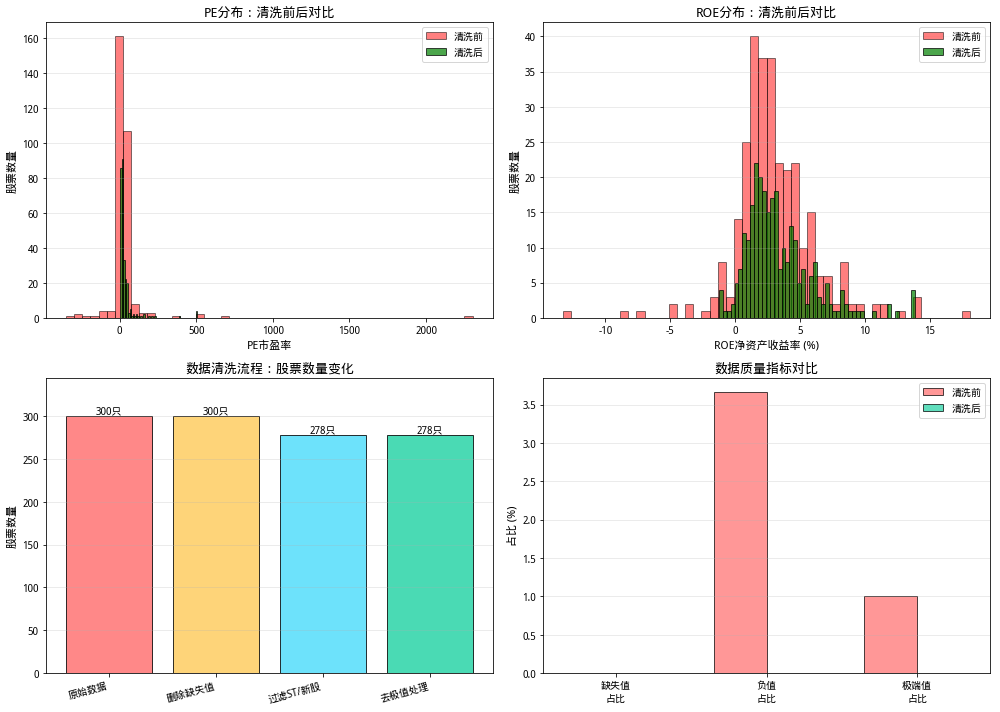


✅ 数据清洗完成！可以看到：
   1. PE/ROE分布更加集中，异常值被控制
   2. 股票池从300只缩减到278只，剔除了不合格样本
   3. 数据质量显著提升，缺失值和极端值被处理


In [55]:
# 清洗前后的数据质量对比
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PE分布对比（清洗前 vs 清洗后）
ax1 = axes[0, 0]
ax1.hist(df_data['pe_ratio'], bins=50, alpha=0.5, color='red', label='清洗前', edgecolor='black')
ax1.hist(df_clean['pe_ratio'], bins=50, alpha=0.7, color='green', label='清洗后', edgecolor='black')
ax1.set_xlabel('PE市盈率', fontsize=11)
ax1.set_ylabel('股票数量', fontsize=11)
ax1.set_title('PE分布：清洗前后对比', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# ROE分布对比
ax2 = axes[0, 1]
ax2.hist(df_data['roe'].dropna(), bins=50, alpha=0.5, color='red', label='清洗前', edgecolor='black')
ax2.hist(df_clean['roe'], bins=50, alpha=0.7, color='green', label='清洗后', edgecolor='black')
ax2.set_xlabel('ROE净资产收益率 (%)', fontsize=11)
ax2.set_ylabel('股票数量', fontsize=11)
ax2.set_title('ROE分布：清洗前后对比', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 股票数量变化
ax3 = axes[1, 0]
stages = ['原始数据', '删除缺失值', '过滤ST/新股', '去极值处理']
counts = [len(df_data),
          len(df_data.dropna(subset=['pe_ratio', 'pb_ratio', 'roe'])),
          len(df_clean[df_clean['pe_ratio'] > 0]),
          len(df_clean)]
colors_bar = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1']
bars = ax3.bar(stages, counts, color=colors_bar, edgecolor='black', alpha=0.8)
ax3.set_ylabel('股票数量', fontsize=11)
ax3.set_title('数据清洗流程：股票数量变化', fontsize=13, fontweight='bold')
ax3.set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(count)}只',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=15, ha='right')

# 数据质量指标
ax4 = axes[1, 1]
metrics = ['缺失值\n占比', '负值\n占比', '极端值\n占比']
before = [
    df_data['roe'].isnull().sum() / len(df_data) * 100,
    ((df_data['pe_ratio'] < 0).sum() + (df_data['pb_ratio'] < 0).sum()) / (len(df_data) * 2) * 100,
    ((df_data['pe_ratio'] > df_data['pe_ratio'].quantile(0.99)).sum() if 'pe_ratio' in df_data.columns else 0) / len(df_data) * 100
]
after = [
    df_clean['roe'].isnull().sum() / len(df_clean) * 100,
    0,  # 已过滤
    0   # 已截尾
]

x = np.arange(len(metrics))
width = 0.35
bars1 = ax4.bar(x - width/2, before, width, label='清洗前', color='#ff6b6b', alpha=0.7, edgecolor='black')
bars2 = ax4.bar(x + width/2, after, width, label='清洗后', color='#1dd1a1', alpha=0.7, edgecolor='black')

ax4.set_ylabel('占比 (%)', fontsize=11)
ax4.set_title('数据质量指标对比', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics, fontsize=10)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ 数据清洗完成！可以看到：")
print(f"   1. PE/ROE分布更加集中，异常值被控制")
print(f"   2. 股票池从{len(df_data)}只缩减到{len(df_clean)}只，剔除了不合格样本")
print(f"   3. 数据质量显著提升，缺失值和极端值被处理")

In [56]:
## 因子计算


In [57]:
## 1. 价值因子 ： 1/PE + 1/PB

In [58]:
## 方向调整
df_clean['value_pe'] = 1 / df_clean['pe_ratio']
df_clean['value_pb'] = 1 / df_clean['pb_ratio']

print("✅ PE倒数示例（盈利收益率）:")
print(df_clean[['pe_ratio', 'value_pe']].head())

✅ PE倒数示例（盈利收益率）:
    pe_ratio  value_pe
0   4.681281  0.213617
2  21.928600  0.045603
3  45.253100  0.022098
4  16.325700  0.061253
5  30.897600  0.032365


In [59]:
## 标准化
## (x - mean) / std
def zscore(series):
    return (series - series.mean()) / series.std()


In [60]:
## value_pe 0.05 -> 1.2
## value_pb 0.3  -> 0.8

df_clean['value_pe_std'] = zscore(df_clean['value_pe'])
df_clean['value_pb_std'] = zscore(df_clean['value_pb'])

In [61]:
df_clean.head()

,code,pe_ratio,pb_ratio,market_cap,roe,inc_revenue_year_on_year,value_pe,value_pb,value_pe_std,value_pb_std
0,000001.XSHE,4.681281,0.5118,2152.1163,2.85,-11.72,0.213617,1.953888,3.039708,2.596468
2,000063.XSHE,21.928600,2.8477,2059.3118,3.05,-3.94,0.045603,0.351161,-0.376753,-0.549427
3,000100.XSHE,45.253100,1.8172,963.3668,1.01,-10.75,0.022098,0.550297,-0.854705,-0.158554
4,000157.XSHE,16.325700,1.0834,618.7408,1.51,-13.89,0.061253,0.923020,-0.058509,0.573041
5,000166.XSHE,30.897600,1.2314,1269.5252,1.68,62.74,0.032365,0.812084,-0.645931,0.355291


In [62]:
## 合成
df_clean['value_score'] = (
    df_clean['value_pe_std'] + df_clean['value_pb_std']
) / 2

print("\n✅ 价值因子Top 10:")
print(df_clean.nlargest(10, 'value_score')[['code', 'pe_ratio', 'pb_ratio', 'value_score']])


✅ 价值因子Top 10:
            code  pe_ratio  pb_ratio  value_score
113  600015.XSHG  4.681281  0.445631     3.102819
207  601169.XSHG  4.698600  0.459600     3.027876
208  601186.XSHG  5.062100  0.445631     2.939429
263  601998.XSHG  5.156000  0.448000     2.891205
221  601390.XSHG  4.776900  0.483700     2.886014
256  601916.XSHG  5.095400  0.454500     2.883328
243  601818.XSHG  5.194700  0.453800     2.848516
230  601668.XSHG  4.681281  0.507200     2.835480
0    000001.XSHE  4.681281  0.511800     2.818088
114  600016.XSHG  5.390500  0.445631     2.817068


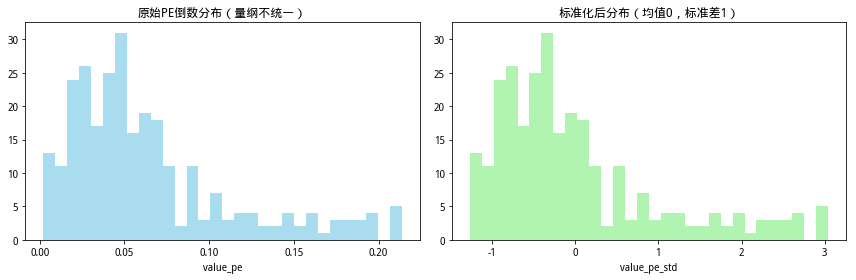

Z-Score的作用：将不同量纲的因子拉到同一水平线！


In [63]:
import matplotlib.pyplot as plt

# 原始PE倒数分布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(df_clean['value_pe'], bins=30, alpha=0.7, color='skyblue')
ax1.set_title('原始PE倒数分布（量纲不统一）')
ax1.set_xlabel('value_pe')

ax2.hist(df_clean['value_pe_std'], bins=30, alpha=0.7, color='lightgreen')
ax2.set_title('标准化后分布（均值0，标准差1）')
ax2.set_xlabel('value_pe_std')

plt.tight_layout()
plt.show()

print("Z-Score的作用：将不同量纲的因子拉到同一水平线！")

In [64]:
## 成长因子  = ROE + 应收增长率

In [65]:
df_clean['roe_std'] = zscore(df_clean['roe'])
df_clean['revenue_growth_std'] = zscore(df_clean['inc_revenue_year_on_year'])

In [66]:
df_clean['growth_score'] = (
    df_clean['roe_std'] * 0.6 +
    df_clean['revenue_growth_std'] * 0.4
)

In [67]:
## 动量因子 - 20日涨幅

In [68]:
close_slice = close_df.loc[:analysis_date]
print(close_slice.head())

code        000001.XSHE  000002.XSHE     ...       688599.XSHG  688981.XSHG
time                                     ...                               
2024-04-30         9.36         7.41     ...             20.59        41.91
2024-05-06         9.44         7.46     ...             20.71        42.56
2024-05-07         9.44         7.52     ...             20.75        42.71
2024-05-08         9.31         7.20     ...             20.26        42.16
2024-05-09         9.33         7.30     ...             21.08        43.72

[5 rows x 300 columns]


In [69]:
momentum_20d = close_slice.pct_change(20).loc[analysis_date]
print(momentum_20d)

code
000001.XSHE   -0.064831
000002.XSHE   -0.091850
000063.XSHE    0.169529
000100.XSHE   -0.011696
000157.XSHE   -0.016153
000166.XSHE   -0.077634
000301.XSHE   -0.029172
000333.XSHE   -0.042612
000338.XSHE    0.044901
000408.XSHE    0.085567
000425.XSHE   -0.002649
000538.XSHE   -0.055191
000568.XSHE   -0.104758
000596.XSHE   -0.036668
000617.XSHE   -0.085470
000625.XSHE   -0.104956
000630.XSHE   -0.025078
000651.XSHE   -0.033466
000661.XSHE   -0.076156
000708.XSHE   -0.069149
000725.XSHE    0.020737
000768.XSHE   -0.007785
000776.XSHE   -0.059925
000786.XSHE    0.014533
000792.XSHE   -0.038005
000800.XSHE   -0.053269
000807.XSHE    0.143777
000858.XSHE   -0.091506
000876.XSHE   -0.084052
000895.XSHE   -0.036408
                 ...   
603369.XSHG   -0.039375
603392.XSHG   -0.082631
603501.XSHG    0.053301
603659.XSHG   -0.146020
603799.XSHG   -0.033825
603806.XSHG   -0.138639
603833.XSHG   -0.119490
603986.XSHG    0.261188
603993.XSHG    0.016224
605117.XSHG    0.024344
605499.XSHG

In [70]:
df_momentum = pd.DataFrame({
    'code': momentum_20d.index,
    'momentum_20d': momentum_20d.values
})

## merge
df_clean = df_clean.merge(df_momentum, on='code', how='left')
print(df_clean.head())


          code   pe_ratio      ...       growth_score  momentum_20d
0  000001.XSHE   4.681281      ...          -0.355980     -0.064831
1  000063.XSHE  21.928600      ...          -0.224113      0.169529
2  000100.XSHE  45.253100      ...          -0.757111     -0.011696
3  000157.XSHE  16.325700      ...          -0.680305     -0.016153
4  000166.XSHE  30.897600      ...           0.215517     -0.077634

[5 rows x 15 columns]


In [71]:
df_clean['momentum_20d'] = df_clean['momentum_20d'].fillna(0)

In [72]:
df_clean['momentum_std'] = zscore(df_clean['momentum_20d'])

In [73]:
print("✅ 动量因子Top 10（最近20天涨幅最大）:")
print(df_clean.nlargest(10, 'momentum_std')[['code', 'momentum_20d', 'momentum_std']])

✅ 动量因子Top 10（最近20天涨幅最大）:
            code  momentum_20d  momentum_std
42   002050.XSHE      0.298956      4.364701
216  601689.XSHG      0.283327      4.165673
130  600183.XSHG      0.274510      4.053395
259  603986.XSHG      0.261188      3.883755
252  603296.XSHG      0.243124      3.653707
185  601100.XSHG      0.209805      3.229412
82   300394.XSHE      0.170346      2.726921
1    000063.XSHE      0.169529      2.716517
57   002463.XSHE      0.160414      2.600440
90   300502.XSHE      0.159811      2.592762


In [74]:
## 市值因子 - 对数市值
## 茅台: 2wy = 9.9
## 小盘股 : 10y = 2.3

In [75]:
df_clean['size_factor'] = np.log(df_clean['market_cap'])

In [76]:
df_clean['size_std'] = -zscore(df_clean['size_factor'])

In [77]:
print("✅ 市值因子示例:")
print(df_clean[['code', 'market_cap', 'size_factor', 'size_std']].head(10))

✅ 市值因子示例:
          code  market_cap  size_factor  size_std
0  000001.XSHE   2152.1163     7.674207 -0.762598
1  000063.XSHE   2059.3118     7.630127 -0.713122
2  000100.XSHE    963.3668     6.870434  0.139563
3  000157.XSHE    618.7408     6.427686  0.636506
4  000166.XSHE   1269.5252     7.146398 -0.170181
5  000333.XSHE   5589.4285     8.628632 -1.833851
6  000338.XSHE   1255.7515     7.135489 -0.157937
7  000408.XSHE    476.0270     6.165475  0.930814
8  000425.XSHE    907.4816     6.810673  0.206639
9  000538.XSHE   1015.7807     6.923413  0.080099


In [78]:
## 流动性因子: 20日的成交额

In [79]:
avg_money = money_df.loc[:analysis_date].tail(20).mean()
print(avg_money.head())

code
000001.XSHE    1.238461e+09
000002.XSHE    1.140553e+09
000063.XSHE    1.145156e+10
000100.XSHE    2.096567e+09
000157.XSHE    4.164559e+08
dtype: float64


In [80]:
df_liquidity = pd.DataFrame({
    'code': avg_money.index,
    'avg_money_20d': avg_money.values
})

In [81]:
df_clean = df_clean.merge(df_liquidity, on='code', how='left')
df_clean['avg_money_20d'] = df_clean['avg_money_20d'].fillna(df_clean['avg_money_20d'].median())
df_clean['liquidity_std'] = zscore(df_clean['avg_money_20d'])


In [82]:
print(df_clean.head())

          code   pe_ratio      ...        avg_money_20d  liquidity_std
0  000001.XSHE   4.681281      ...         1.238461e+09       0.162366
1  000063.XSHE  21.928600      ...         1.145156e+10       7.470479
2  000100.XSHE  45.253100      ...         2.096567e+09       0.776395
3  000157.XSHE  16.325700      ...         4.164559e+08      -0.425830
4  000166.XSHE  30.897600      ...         4.367572e+08      -0.411304

[5 rows x 20 columns]


In [83]:
print("✅ 所有因子列:")
print([col for col in df_clean.columns if '_std' in col or '_score' in col])

✅ 所有因子列:
['value_pe_std', 'value_pb_std', 'value_score', 'roe_std', 'revenue_growth_std', 'growth_score', 'momentum_std', 'size_std', 'liquidity_std']


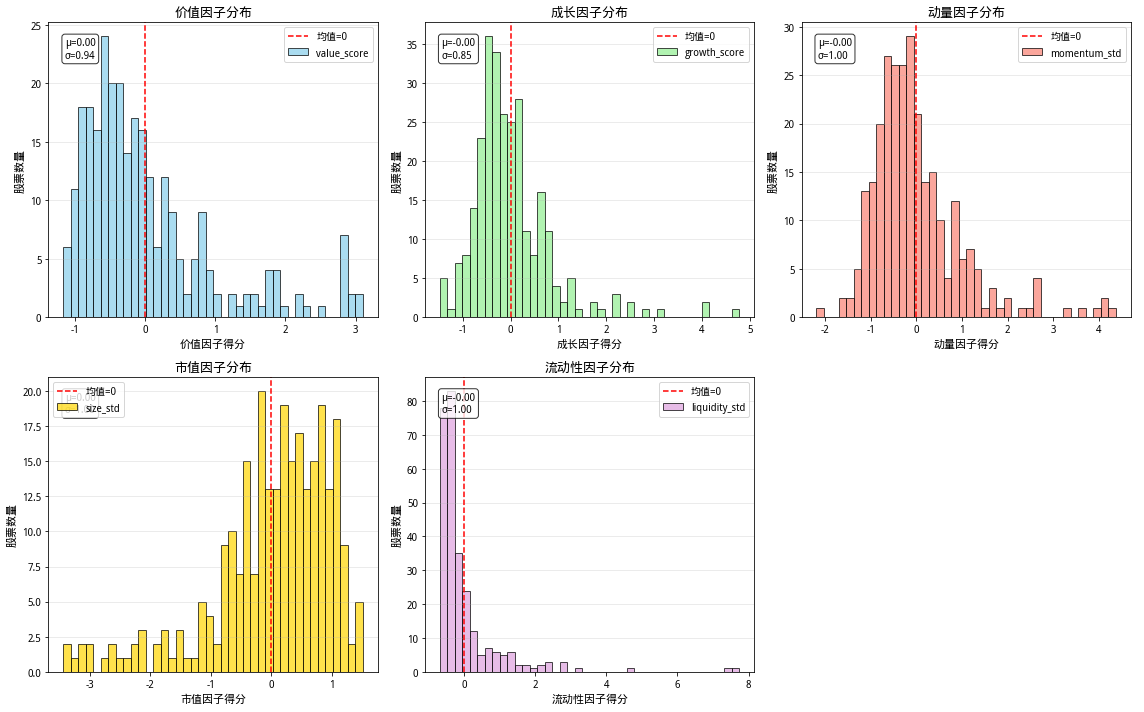

In [84]:
# ========== 1. 因子分布对比（5个因子） ==========
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

factors_info = [
    ('value_score', '价值因子', 'skyblue'),
    ('growth_score', '成长因子', 'lightgreen'),
    ('momentum_std', '动量因子', 'salmon'),
    ('size_std', '市值因子', 'gold'),
    ('liquidity_std', '流动性因子', 'plum'),
]

for idx, (factor, name, color) in enumerate(factors_info):
    ax = axes[idx]
    ax.hist(df_clean[factor], bins=40, color=color, alpha=0.7, edgecolor='black')
    ax.set_title(f'{name}分布', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{name}得分', fontsize=11)
    ax.set_ylabel('股票数量', fontsize=11)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='均值=0')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

    # 添加统计信息
    mean_val = df_clean[factor].mean()
    std_val = df_clean[factor].std()
    ax.text(0.05, 0.95, f'μ={mean_val:.2f}\nσ={std_val:.2f}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 移除多余的子图
axes[-1].axis('off')

plt.tight_layout()
plt.show()


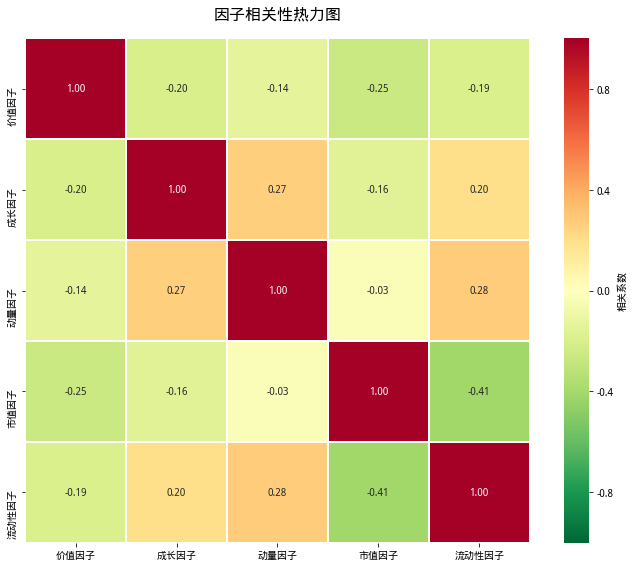


💡 因子相关性解读：
   - 相关系数接近0：因子独立，信息互补 ✅
   - 相关系数>0.7：因子高度相关，可能冗余 ⚠️
   - 相关系数<-0.5：因子负相关，需要注意方向


In [85]:

# ========== 2. 因子相关性热力图 ==========
import seaborn as sns

correlation_matrix = df_clean[[f[0] for f in factors_info]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,           # 显示数值
    fmt='.2f',            # 两位小数
    cmap='RdYlGn_r',      # 红黄绿配色（反向）
    center=0,             # 以0为中心
    vmin=-1, vmax=1,      # 相关系数范围
    square=True,          # 正方形格子
    linewidths=1,         # 格子边框
    cbar_kws={'label': '相关系数'},
    xticklabels=[f[1] for f in factors_info],
    yticklabels=[f[1] for f in factors_info]
)
plt.title('因子相关性热力图', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n💡 因子相关性解读：")
print("   - 相关系数接近0：因子独立，信息互补 ✅")
print("   - 相关系数>0.7：因子高度相关，可能冗余 ⚠️")
print("   - 相关系数<-0.5：因子负相关，需要注意方向")


In [87]:
## 多因子合成和选股

In [89]:
# ========== 方案1：等权合成（最简单）==========
df_clean['composite_score_equal'] = (
    df_clean['value_score'] +      # 价值因子
    df_clean['growth_score'] +     # 成长因子
    df_clean['momentum_std'] +     # 动量因子
    df_clean['size_std'] +         # 市值因子
    df_clean['liquidity_std']      # 流动性因子
) / 5

# ========== 方案2：加权合成（推荐）==========
# 根据重要性分配权重
weights = {
    'value_score': 0.25,      # 价值 25%
    'growth_score': 0.25,     # 成长 25%
    'momentum_std': 0.20,     # 动量 20%
    'size_std': 0.15,         # 市值 15%
    'liquidity_std': 0.15,    # 流动性 15%
}

df_clean['composite_score'] = (
    df_clean['value_score'] * 0.25 +
    df_clean['growth_score'] * 0.25 +
    df_clean['momentum_std'] * 0.20 +
    df_clean['size_std'] * 0.15 +
    df_clean['liquidity_std'] * 0.15
)

print("✅ 权重分配:")
for factor, weight in weights.items():
    print(f"  {factor:20s}: {weight:.0%}")

✅ 权重分配:
  value_score         : 25%
  growth_score        : 25%
  momentum_std        : 20%
  size_std            : 15%
  liquidity_std       : 15%


In [90]:
## 最终选股

In [91]:
df_clean = df_clean.sort_values('composite_score', ascending=False)


In [92]:
top_20 = df_clean.head(20)
print(top_20)

            code       ...         composite_score
90   300502.XSHE       ...                1.555164
1    000063.XSHE       ...                1.385106
187  601127.XSHG       ...                1.281070
42   002050.XSHE       ...                0.992599
82   300394.XSHE       ...                0.991295
202  601336.XSHG       ...                0.987552
259  603986.XSHG       ...                0.984291
261  605117.XSHG       ...                0.890349
79   300308.XSHE       ...                0.840467
216  601689.XSHG       ...                0.822459
240  601919.XSHG       ...                0.776627
57   002463.XSHE       ...                0.756379
252  603296.XSHG       ...                0.731656
24   000807.XSHE       ...                0.707251
130  600183.XSHG       ...                0.662821
239  601916.XSHG       ...                0.656328
190  601166.XSHG       ...                0.621952
191  601169.XSHG       ...                0.619881
30   000975.XSHE       ...     

In [93]:
# 格式化输出
for idx, row in top_20.iterrows():
    print(f"{row['code']} | "
          f"PE:{row['pe_ratio']:6.2f} PB:{row['pb_ratio']:5.2f} | "
          f"ROE:{row['roe']:5.1f}% | "
          f"营收增长:{row['inc_revenue_year_on_year']:6.1f}% | "
          f"20日涨幅:{row['momentum_20d']*100:5.1f}% | "
          f"综合得分:{row['composite_score']:5.2f}")

# ========== 统计信息 ==========
print("\n📊 选股池统计:")
print(f"  平均PE: {top_20['pe_ratio'].mean():.2f}")
print(f"  平均PB: {top_20['pb_ratio'].mean():.2f}")
print(f"  平均ROE: {top_20['roe'].mean():.2f}%")
print(f"  平均营收增长: {top_20['inc_revenue_year_on_year'].mean():.2f}%")
print(f"  平均20日涨幅: {top_20['momentum_20d'].mean()*100:.2f}%")

300502.XSHE | PE: 52.65 PB:14.16 | ROE: 11.7% | 营收增长: 207.1% | 20日涨幅: 16.0% | 综合得分: 1.56
000063.XSHE | PE: 21.93 PB: 2.85 | ROE:  3.0% | 营收增长:  -3.9% | 20日涨幅: 17.0% | 综合得分: 1.39
601127.XSHG | PE: 51.29 PB:14.76 | ROE: 13.8% | 营收增长: 228.0% | 20日涨幅:  0.4% | 综合得分: 1.28
002050.XSHE | PE: 36.80 PB: 6.11 | ROE:  4.3% | 营收增长:   6.8% | 20日涨幅: 29.9% | 综合得分: 0.99
300394.XSHE | PE: 50.71 PB:16.60 | ROE:  8.7% | 营收增长:  54.8% | 20日涨幅: 17.0% | 综合得分: 0.99
601336.XSHG | PE:  7.21 PB: 1.57 | ROE: 10.6% | 营收增长: 228.0% | 20日涨幅:-10.3% | 综合得分: 0.99
603986.XSHG | PE:161.64 PB: 5.66 | ROE:  2.0% | 营收增长:  42.8% | 20日涨幅: 26.1% | 综合得分: 0.98
605117.XSHG | PE: 22.62 PB: 5.94 | ROE: 11.7% | 营收增长: 128.2% | 20日涨幅:  2.4% | 综合得分: 0.89
300308.XSHE | PE: 31.96 PB: 8.38 | ROE:  8.2% | 营收增长: 115.2% | 20日涨幅:  0.3% | 综合得分: 0.84
601689.XSHG | PE: 38.97 PB: 5.82 | ROE:  4.2% | 营收增长:  42.9% | 20日涨幅: 28.3% | 综合得分: 0.82
601919.XSHG | PE:  5.62 PB: 1.01 | ROE:  9.8% | 营收增长:  72.2% | 20日涨幅: -6.8% | 综合得分: 0.78
002463.XSHE | PE: 36.

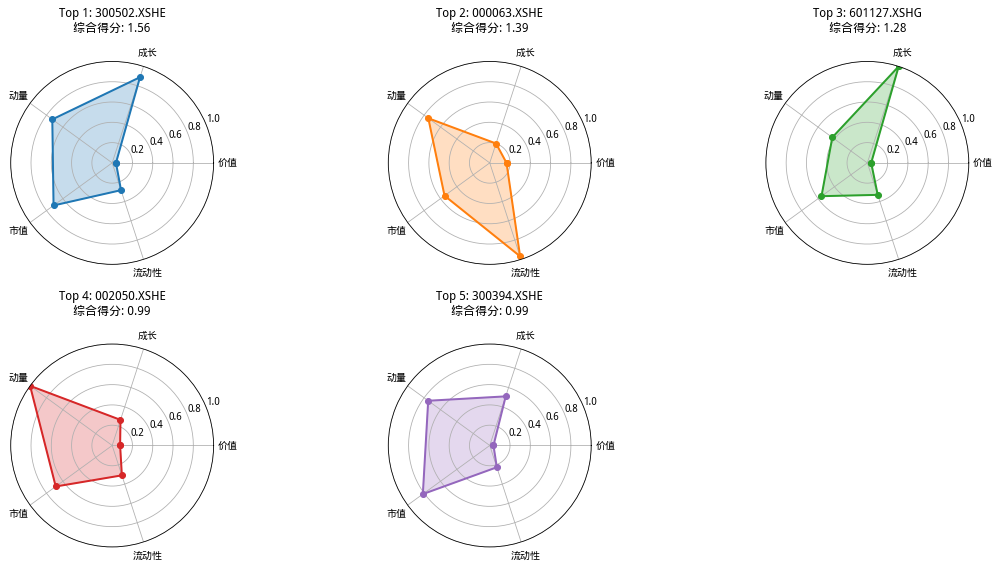

In [94]:
import numpy as np
from math import pi

# 选择前5只股票
top_5 = df_clean.head(5)
categories = ['价值', '成长', '动量', '市值', '流动性']
N = len(categories)

# 创建雷达图
fig = plt.figure(figsize=(16, 8))

for i, (idx, row) in enumerate(top_5.iterrows()):
    ax = plt.subplot(2, 3, i+1, projection='polar')

    # 数据归一化到0-1（用于雷达图展示）
    values = [
        (row['value_score'] - df_clean['value_score'].min()) / (df_clean['value_score'].max() - df_clean['value_score'].min()),
        (row['growth_score'] - df_clean['growth_score'].min()) / (df_clean['growth_score'].max() - df_clean['growth_score'].min()),
        (row['momentum_std'] - df_clean['momentum_std'].min()) / (df_clean['momentum_std'].max() - df_clean['momentum_std'].min()),
        (row['size_std'] - df_clean['size_std'].min()) / (df_clean['size_std'].max() - df_clean['size_std'].min()),
        (row['liquidity_std'] - df_clean['liquidity_std'].min()) / (df_clean['liquidity_std'].max() - df_clean['liquidity_std'].min()),
    ]
    values += values[:1]  # 闭合图形

    # 角度
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # 绘制
    ax.plot(angles, values, 'o-', linewidth=2, label=row['code'], color=f'C{i}')
    ax.fill(angles, values, alpha=0.25, color=f'C{i}')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(f"Top {i+1}: {row['code']}\n综合得分: {row['composite_score']:.2f}",
                 fontsize=12, fontweight='bold', pad=20)
    ax.grid(True)

plt.tight_layout()
plt.show()

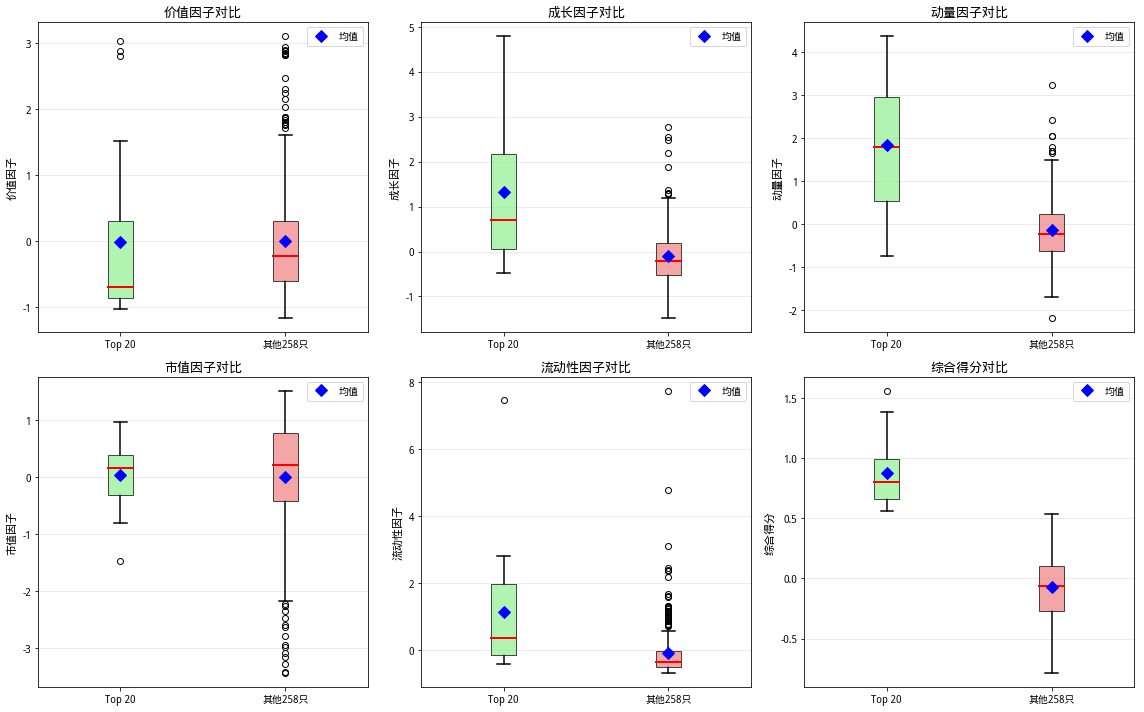


💡 从箱线图可以看到：
   - Top 20在各个因子上的中位数（红线）都显著高于其他股票
   - Top 20的因子分布更集中在高分区
   - 综合得分的差距最为明显


In [95]:

# ========== 2. Top 20 vs 其他股票的因子对比（箱线图） ==========
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

factors_compare = [
    ('value_score', '价值因子'),
    ('growth_score', '成长因子'),
    ('momentum_std', '动量因子'),
    ('size_std', '市值因子'),
    ('liquidity_std', '流动性因子'),
    ('composite_score', '综合得分'),
]

top_20_codes = top_20['code'].tolist()

for idx, (factor, name) in enumerate(factors_compare):
    ax = axes[idx]

    top_20_values = df_clean[df_clean['code'].isin(top_20_codes)][factor]
    others_values = df_clean[~df_clean['code'].isin(top_20_codes)][factor]

    bp = ax.boxplot(
        [top_20_values, others_values],
        labels=['Top 20', f'其他{len(df_clean)-20}只'],
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', alpha=0.7),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5)
    )
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')

    ax.set_ylabel(f'{name}', fontsize=11)
    ax.set_title(f'{name}对比', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # 添加均值标记
    means = [top_20_values.mean(), others_values.mean()]
    ax.plot([1, 2], means, 'D', color='blue', markersize=8, label='均值', zorder=3)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n💡 从箱线图可以看到：")
print("   - Top 20在各个因子上的中位数（红线）都显著高于其他股票")
print("   - Top 20的因子分布更集中在高分区")
print("   - 综合得分的差距最为明显")

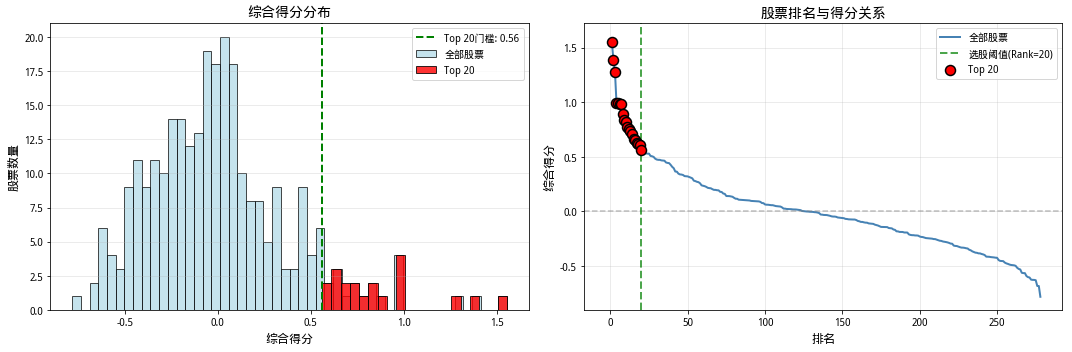


✅ 选股池确定！Top 20的得分范围：0.56 ~ 1.56


In [96]:
# ========== 3. 综合得分分布图 ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 左图：得分直方图 + Top 20 标记
ax1.hist(df_clean['composite_score'], bins=50, color='lightblue',
         edgecolor='black', alpha=0.7, label='全部股票')
ax1.hist(top_20['composite_score'], bins=20, color='red',
         edgecolor='black', alpha=0.8, label='Top 20')
ax1.axvline(top_20['composite_score'].min(), color='green',
            linestyle='--', linewidth=2, label=f'Top 20门槛: {top_20["composite_score"].min():.2f}')
ax1.set_xlabel('综合得分', fontsize=12)
ax1.set_ylabel('股票数量', fontsize=12)
ax1.set_title('综合得分分布', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 右图：排名曲线
df_clean_sorted = df_clean.sort_values('composite_score', ascending=False).reset_index(drop=True)
df_clean_sorted['rank'] = range(1, len(df_clean_sorted) + 1)

ax2.plot(df_clean_sorted['rank'], df_clean_sorted['composite_score'],
         linewidth=2, color='steelblue', label='全部股票')
ax2.scatter(range(1, 21), top_20['composite_score'].sort_values(ascending=False).values,
            s=100, color='red', zorder=5, label='Top 20', edgecolors='black', linewidths=1.5)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(20, color='green', linestyle='--', linewidth=2, alpha=0.7, label='选股阈值(Rank=20)')
ax2.set_xlabel('排名', fontsize=12)
ax2.set_ylabel('综合得分', fontsize=12)
ax2.set_title('股票排名与得分关系', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ 选股池确定！Top 20的得分范围：{top_20['composite_score'].min():.2f} ~ {top_20['composite_score'].max():.2f}")

In [ ]:
## 课程预告